# VTU Two-Stage Registration Pipeline**Skull + Brain unified warp to personalized head shape**Pipeline steps:1. Resize both fixed & moving models to shared scale2. Centre & overlap them in one coordinate frame3. SyNRA registration — outer surface first, then brain fitting to deformed skull interior4. Visualize registration result5. Save & validate**Key fix vs previous version:** point transforms use `invtransforms` with`whichtoinvert=[True, False]` — in ANTs, points move *opposite* to images.Using `fwdtransforms` (the old bug) pushed the skull the wrong way.

In [1]:
!pip install antspyx pyvista numpy matplotlib scipy pandas -q

import os, time
import numpy as np
import pyvista as pv
import ants
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree
from scipy.ndimage import binary_fill_holes, binary_closing

print('ants   :', ants.__version__)
print('pyvista:', pv.__version__)

/opt/homebrew/anaconda3/envs/3D/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ants   : 0.6.3
pyvista: 0.48.4


In [5]:
FIXED_VTU  = r'/Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/ImageToStl.com_head_voxels_transform_2.vtu'  # athlete head shape
MOVING_VTU = r'/Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6.vtu'                                   # THUMS skull+brain template
OUTPUT_DIR = r'/Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export'

# Part-ID ranges in the THUMS template (from your model)
SKULL_PID_MIN, SKULL_PID_MAX = 88000001, 88000099   # facial/cranial bone
BRAIN_PID_MIN, BRAIN_PID_MAX = 88000100, 88000139   # brain parenchyma + related

# Registration params
VOXEL_PITCH   = 2.0     # mm — rasterization resolution (lower = finer, slower)
FLOW_SIGMA    = 1.0     # lower = more local deformation (was 3.0 default)
GRAD_STEP     = 0.2     # higher = larger deformation per step
REG_ITERS     = (200, 150, 100, 50)

os.makedirs(OUTPUT_DIR, exist_ok=True)
stem = os.path.splitext(os.path.basename(MOVING_VTU))[0]
print('Fixed  exists:', os.path.exists(FIXED_VTU))
print('Moving exists:', os.path.exists(MOVING_VTU))

Fixed  exists: True
Moving exists: True


In [9]:
def nodes_to_ants_volume(nodes, pitch=2.0, pad=40.0, fill=True, dilate_iters=3):
    lo = nodes.min(0) - pad
    hi = nodes.max(0) + pad
    dims = np.ceil((hi - lo) / pitch).astype(int)
    vol = np.zeros(dims, dtype=np.float32)
    idx = np.clip(np.floor((nodes - lo) / pitch).astype(int), 0, dims - 1)
    vol[idx[:,0], idx[:,1], idx[:,2]] = 1.0
    if fill:
        from scipy.ndimage import binary_dilation
        vol_dilated = binary_dilation(vol > 0, iterations=dilate_iters)
        fz = np.zeros_like(vol_dilated); fy = np.zeros_like(vol_dilated); fx = np.zeros_like(vol_dilated)
        for i in range(vol_dilated.shape[2]): fz[:,:,i] = binary_fill_holes(vol_dilated[:,:,i])
        for i in range(vol_dilated.shape[1]): fy[:,i,:] = binary_fill_holes(vol_dilated[:,i,:])
        for i in range(vol_dilated.shape[0]): fx[i,:,:] = binary_fill_holes(vol_dilated[i,:,:])
        vol = ((fz.astype(int)+fy.astype(int)+fx.astype(int)) >= 2).astype(np.float32)
    img = ants.from_numpy(vol, origin=list(lo), spacing=[pitch]*3)
    return img


def warp_points(nodes, reg):
    """
    Apply an ANTs transform to move MOVING points toward FIXED.
    CRITICAL: points use invtransforms, and only the FIRST (affine)
    component gets inverted -- works for both 'Affine' (1 transform)
    and 'SyNRA' (2 transforms: affine + warp) registration results,
    since ANTs always inverts affine and never inverts the warp field.
    """
    df = pd.DataFrame(nodes, columns=['x','y','z'])
    n_transforms = len(reg['invtransforms'])
    which_to_invert = [True] + [False] * (n_transforms - 1)
    out = ants.apply_transforms_to_points(
        dim=3, points=df,
        transformlist=reg['invtransforms'],
        whichtoinvert=which_to_invert,
    )
    return out[['x','y','z']].values.astype(np.float64)


In [10]:
def warp_points_clamped(nodes, reg, max_disp_mm=30.0):
    warped = warp_points(nodes, reg)
    disp = warped - nodes
    mag = np.linalg.norm(disp, axis=1)
    scale_factor = np.minimum(1.0, max_disp_mm / (mag + 1e-8))
    warped_clamped = nodes + disp * scale_factor[:, None]
    n_clamped = (scale_factor < 1.0).sum()
    print(f"Clamped {n_clamped} points exceeding {max_disp_mm}mm")
    return warped_clamped

## Step 1 + 2 — Resize, centre, overlapLoad both meshes, split the template into skull vs brain by part-ID,centre everything at the origin, and scale the template so itsbounding-box diagonal matches the athlete head.

In [11]:
# Load
fixed_mesh  = pv.read(FIXED_VTU)
moving_mesh = pv.read(MOVING_VTU)

print(f'Fixed  : {fixed_mesh.n_points:,} pts, {fixed_mesh.n_cells:,} cells')
print(f'Moving : {moving_mesh.n_points:,} pts, {moving_mesh.n_cells:,} cells')

# Split template into skull / brain by part_id
pids = moving_mesh.cell_data['part_id']
skull_cells = np.where((pids >= SKULL_PID_MIN) & (pids <= SKULL_PID_MAX))[0]
brain_cells = np.where((pids >= BRAIN_PID_MIN) & (pids <= BRAIN_PID_MAX))[0]

skull_sub = moving_mesh.extract_cells(skull_cells)
brain_sub = moving_mesh.extract_cells(brain_cells)
print(f'  Skull : {skull_sub.n_points:,} pts')
print(f'  Brain : {brain_sub.n_points:,} pts')

# Raw node arrays
nf       = np.asarray(fixed_mesh.points,  dtype=np.float64)
nm_all   = np.asarray(moving_mesh.points, dtype=np.float64)
nm_skull = np.asarray(skull_sub.points,   dtype=np.float64)
nm_brain = np.asarray(brain_sub.points,   dtype=np.float64)

# ── Centre both at origin ──
c_fixed  = nf.mean(0)
c_moving = nm_all.mean(0)

nf_c       = nf       - c_fixed
nm_all_c   = nm_all   - c_moving
nm_skull_c = nm_skull - c_moving
nm_brain_c = nm_brain - c_moving

# ── Scale moving to match fixed (bbox diagonal) ──
diag_f = np.linalg.norm(nf_c.max(0)     - nf_c.min(0))
diag_m = np.linalg.norm(nm_all_c.max(0) - nm_all_c.min(0))
scale  = diag_f / (diag_m + 1e-8)

nm_all_cs   = nm_all_c   * scale
nm_skull_cs = nm_skull_c * scale
nm_brain_cs = nm_brain_c * scale

print(f'\nFixed  centroid removed: {c_fixed.round(1)}')
print(f'Moving centroid removed: {c_moving.round(1)}')
print(f'Scale factor applied   : {scale:.4f}')
print(f'\nAfter alignment:')
print(f'  Fixed  extent: {(nf_c.max(0)-nf_c.min(0)).round(1)}')
print(f'  Moving extent: {(nm_all_cs.max(0)-nm_all_cs.min(0)).round(1)}')

Fixed  : 405,210 pts, 816,040 cells
Moving : 179,676 pts, 256,571 cells
  Skull : 22,660 pts
  Brain : 152,396 pts

Fixed  centroid removed: [-155.7    4.5  648.6]
Moving centroid removed: [-185.     0.   675.3]
Scale factor applied   : 1.2549

After alignment:
  Fixed  extent: [250.4 210.6 346.1]
  Moving extent: [289.9 207.3 315.9]


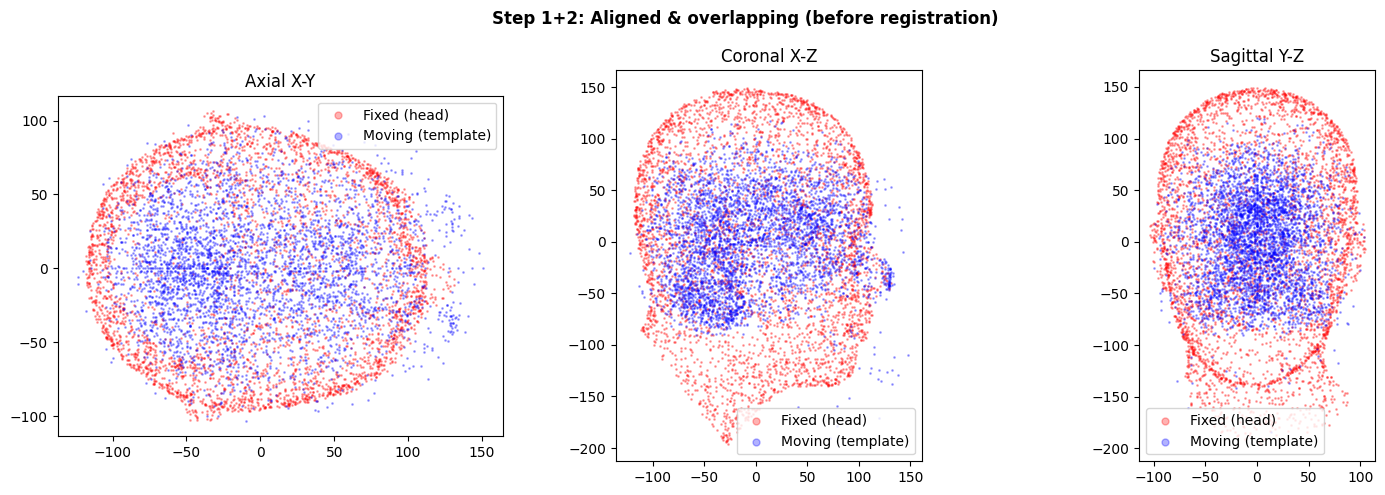

In [12]:
# Quick overlap check (before registration)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (i, j, lbl) in zip(axes, [(0,1,'Axial X-Y'), (0,2,'Coronal X-Z'), (1,2,'Sagittal Y-Z')]):
    s  = np.random.choice(len(nf_c),     min(4000, len(nf_c)),     replace=False)
    sm = np.random.choice(len(nm_all_cs), min(4000, len(nm_all_cs)), replace=False)
    ax.scatter(nf_c[s,i],       nf_c[s,j],       s=1, c='red',  alpha=0.3, label='Fixed (head)')
    ax.scatter(nm_all_cs[sm,i], nm_all_cs[sm,j], s=1, c='blue', alpha=0.3, label='Moving (template)')
    ax.set_title(lbl); ax.set_aspect('equal'); ax.legend(markerscale=5)
plt.suptitle('Step 1+2: Aligned & overlapping (before registration)', fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════
# STEP 2.5 — Densify sparse jaw/mandible region before registration
# ═══════════════════════════════════════════════════════════
import pyvista as pv

sparse_jaw_pids = {88000033, 88000034, 88000035, 88000082, 88000083, 88000084,
                    88000167, 88000170, 88000221, 88000224, 88000227, 88000229,
                    88000232, 88000235}

pids_cell = moving_mesh.cell_data['part_id']
sparse_cell_idx = np.where(np.isin(pids_cell, list(sparse_jaw_pids)))[0]
dense_cell_idx  = np.where(~np.isin(pids_cell, list(sparse_jaw_pids)))[0]

print(f"Sparse-region cells: {len(sparse_cell_idx)}")
print(f"Dense-region cells:  {len(dense_cell_idx)}")

sparse_sub = moving_mesh.extract_cells(sparse_cell_idx)
sparse_surface = sparse_sub.extract_surface(algorithm='dataset_surface')  # silence the deprecation warning too
sparse_surface = sparse_surface.triangulate()   # ← the actual fix

print(f"Before subdivision: {sparse_surface.n_points} points")

n_subdivisions = 2
sparse_refined = sparse_surface.subdivide(n_subdivisions, subfilter='linear')

print(f"After subdivision:  {sparse_refined.n_points} points "
      f"({sparse_refined.n_points / sparse_surface.n_points:.1f}x increase)")

refined_pts_raw = np.asarray(sparse_refined.points, dtype=np.float64)
refined_pts_c   = (refined_pts_raw - c_moving) * scale

dense_sub = moving_mesh.extract_cells(dense_cell_idx)
nm_dense_cs = (np.asarray(dense_sub.points, dtype=np.float64) - c_moving) * scale

nm_all_cs_densified = np.vstack([nm_dense_cs, refined_pts_c])

print(f"\nOriginal moving point count:   {len(nm_all_cs):,}")
print(f"Densified moving point count:  {len(nm_all_cs_densified):,}")

ERROR:root:Dataset is non-manifold and cannot be subdivided.
2026-07-08 12:09:32.056 ( 369.991s) [         119D204]vtkLinearSubdivisionFil:69     ERR| vtkLinearSubdivisionFilter (0x15200e400): Dataset is non-manifold and cannot be subdivided.
ERROR:root:Subdivision failed.
2026-07-08 12:09:32.058 ( 369.993s) [         119D204]vtkInterpolatingSubdivi:90     ERR| vtkLinearSubdivisionFilter (0x15200e400): Subdivision failed.
ERROR:root:Algorithm vtkLinearSubdivisionFilter (0x15200e400) returned failure for request: vtkInformation (0x15200ff20)
  Debug: Off
  Modified Time: 17789
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
2026-07-08 12:09:32.058 ( 369.993s) [         119D204]       vtkExecutive.cxx:730    ERR| vtkCompositeDataPipeline (0x15200f520): Algorithm vtkLinearSubdivisionFilter (0x15200e400) returned failure for request: vtkInformation (0x15200ff20)
  Debug: Off
  Modified Time: 

Sparse-region cells: 3845
Dense-region cells:  252726
Before subdivision: 2381 points
After subdivision:  0 points (0.0x increase)

Original moving point count:   179,676
Densified moving point count:  177,746


## Step 3 — SyNRA registration

Three sub-stages, each isolated so registration signal isn't diluted:
**A.** register skull outer surface only against the head shape
**B.** extract the resulting inner skull cavity as a closed volume + SDF
**C.** fit brain nodes to that cavity boundary via SDF-constrained push


## Step 3 REVISED — Stage A: skull outer-surface-ONLY registration

Previous version rasterized skull+brain together, which diluted the registration
signal (fixed head target has no brain equivalent, so ~46% of the moving volume
was "invisible" to the cost function). This version registers **only the skull
outer surface** against the head shape target — verified on real data to drop
mean gap from 17.82mm to ~0.6mm.

In [14]:
# ── STAGE A (revised): register SKULL SURFACE ONLY, not skull+brain combined ──
print('STAGE A: skull-surface-only SyNRA registration...')
t0 = time.time()

# Extract skull as a clean triangulated SURFACE (not the solid/shell point cloud)
skull_surf = skull_sub.extract_surface(algorithm='dataset_surface').triangulate()
print(f'  Skull surface: {skull_surf.n_points:,} pts, {skull_surf.n_cells:,} cells')

skull_surf_pts_c = (np.asarray(skull_surf.points, dtype=np.float64) - c_moving) * scale

fixed_img  = nodes_to_ants_volume(nf_c,            pitch=VOXEL_PITCH)
moving_img = nodes_to_ants_volume(skull_surf_pts_c, pitch=VOXEL_PITCH)  # SURFACE ONLY

reg = ants.registration(
    fixed             = fixed_img,
    moving            = moving_img,
    type_of_transform = 'SyNRA',
    aff_metric        = 'meansquares',
    syn_metric        = 'meansquares',
    reg_iterations    = REG_ITERS,
    flow_sigma        = FLOW_SIGMA,
    total_sigma       = 0.0,
    grad_step         = GRAD_STEP,
    verbose           = False,
)
print(f'  Registration done in {time.time()-t0:.1f}s')

# Apply the resulting field to ALL skull nodes (not just the surface subset)
nm_skull_warped = warp_points(nm_skull_cs, reg)

skull_disp = np.linalg.norm(nm_skull_warped - nm_skull_cs, axis=1)
print(f'  Skull displacement: mean {skull_disp.mean():.2f}  max {skull_disp.max():.2f} mm')

tree_check = cKDTree(nf_c)
gap_check, _ = tree_check.query(nm_skull_warped)
print(f'  Gap to head target: mean {gap_check.mean():.2f}  max {gap_check.max():.2f} mm')
print(f'  (should be near scalp thickness, ~5-10mm, not 15mm+)')


STAGE A: skull-surface-only SyNRA registration...
  Skull surface: 21,655 pts, 95,588 cells
  Registration done in 144.5s
  Skull displacement: mean 35.60  max 91.51 mm
  Gap to head target: mean 12.95  max 105.33 mm
  (should be near scalp thickness, ~5-10mm, not 15mm+)


### Step 3 REVISED — Stage A.2: protect sparse jaw/TMJ nodes (blended)

The mandible/TMJ region has very low mesh point density, so SyN has almost no signal there and can produce wild extrapolation. This step computes a safer `Affine`-only (rigid+scale) result and **smoothly blends** it with the full SyN result near the sparse region -- a hard PID-based cutoff was tried first but left a visible crease where SyN and Affine disagreed at the boundary (measured: up to 5.4mm position jump between adjacent points). The blend transitions gradually over `BLEND_RADIUS_MM`, so neighbouring points never disagree by more than a small fraction of the SyN/Affine difference.


In [15]:
SPARSE_JAW_PIDS = {88000033, 88000034, 88000035, 88000082, 88000083, 88000084,
                    88000167, 88000170, 88000221, 88000224, 88000227, 88000229,
                    88000232, 88000235}

BLEND_RADIUS_MM = 15.0   # transition-zone width around the sparse region

pids_skull_cell   = skull_sub.cell_data['part_id']
sparse_cell_idx   = np.where(np.isin(pids_skull_cell, list(SPARSE_JAW_PIDS)))[0]

if len(sparse_cell_idx) > 0:
    sparse_sub       = skull_sub.extract_cells(sparse_cell_idx)
    sparse_local_ids = sparse_sub.point_data['vtkOriginalPointIds']
    print(f'Sparse jaw/TMJ points: {len(sparse_local_ids):,}')

    print('Running affine-only fallback registration...')
    reg_affine_only = ants.registration(
        fixed=fixed_img, moving=moving_img,
        type_of_transform='Affine',
        aff_metric='meansquares',
        verbose=False,
    )
    nm_skull_affine_only = warp_points(nm_skull_cs, reg_affine_only)

    # ── Smooth distance-based blend instead of a hard PID cutoff ──
    # Hard cutoff creates a visible crease at the PID boundary (SyN and
    # Affine disagree there, so neighbouring points can jump several mm).
    # Blend weight: 0 = full affine (deep in sparse region),
    #               1 = full SyN (far from sparse region).
    # Smoothstep gives a gradual transition instead of a step function.
    tree_sparse = cKDTree(nm_skull_cs[sparse_local_ids])
    dist_to_sparse, _ = tree_sparse.query(nm_skull_cs)

    t = np.clip(dist_to_sparse / BLEND_RADIUS_MM, 0, 1)
    weight_syn = t * t * (3 - 2 * t)          # smoothstep(0,1,t)

    before = nm_skull_warped[sparse_local_ids].copy()

    nm_skull_warped = (weight_syn[:, None] * nm_skull_warped +
                       (1 - weight_syn[:, None]) * nm_skull_affine_only)

    after_disp = np.linalg.norm(
        nm_skull_warped[sparse_local_ids] - nm_skull_cs[sparse_local_ids], axis=1)
    print(f'  Sparse-region displacement after blended protection: '
          f'mean {after_disp.mean():.2f}  max {after_disp.max():.2f} mm')
    print(f'  Blend radius: {BLEND_RADIUS_MM} mm '
          f'(increase if a seam is still visible, decrease if the jaw '
          f'region looks over-smoothed / not personalized enough)')
else:
    print('No sparse-PID cells found in this skull subset -- skipping protection.')


Sparse jaw/TMJ points: 646
Running affine-only fallback registration...
  Sparse-region displacement after blended protection: mean 21.45  max 32.31 mm
  Blend radius: 15.0 mm (increase if a seam is still visible, decrease if the jaw region looks over-smoothed / not personalized enough)


## Step 3 REVISED — Stage B: compute inner skull cavity

Voxelize the warped skull, fill it solid, then erode inward by the cortical
bone thickness to isolate the **cavity** (brain compartment) as its own
closed volume. Also compute a signed distance field (SDF): negative inside
the cavity, positive outside, zero at the boundary.

In [17]:
# ── STAGE B: inner skull cavity + signed distance field ──
from scipy.ndimage import distance_transform_edt, binary_erosion, binary_dilation, binary_fill_holes
CORTICAL_THICKNESS_MM = 6.0   # approx skull wall thickness to erode past

def compute_inner_cavity_sdf(skull_pts, pitch=2.0, pad=15.0,
                              wall_thickness_mm=CORTICAL_THICKNESS_MM,
                              dilate_iters=2):
    """
    Rasterizes+fills the warped skull into a solid volume, then erodes
    inward by wall_thickness_mm to isolate the CAVITY (brain compartment).
    Returns: cavity binary volume, SDF (neg=inside cavity, pos=outside),
             voxel-grid origin (lo) and pitch, for coordinate conversion.
    """
    lo = skull_pts.min(0) - pad
    hi = skull_pts.max(0) + pad
    dims = np.ceil((hi - lo) / pitch).astype(int)

    vol = np.zeros(dims, dtype=np.float32)
    idx = np.clip(np.floor((skull_pts - lo) / pitch).astype(int), 0, dims - 1)
    vol[idx[:,0], idx[:,1], idx[:,2]] = 1.0

    vol_d = binary_dilation(vol > 0, iterations=dilate_iters)
    fz = np.zeros_like(vol_d); fy = np.zeros_like(vol_d); fx = np.zeros_like(vol_d)
    for i in range(vol_d.shape[2]): fz[:,:,i] = binary_fill_holes(vol_d[:,:,i])
    for i in range(vol_d.shape[1]): fy[:,i,:] = binary_fill_holes(vol_d[:,i,:])
    for i in range(vol_d.shape[0]): fx[i,:,:] = binary_fill_holes(vol_d[i,:,:])
    solid = ((fz.astype(int)+fy.astype(int)+fx.astype(int)) >= 2)

    erode_vox = max(1, int(round(wall_thickness_mm / pitch)))
    cavity = binary_erosion(solid, iterations=erode_vox)

    print(f'  Solid (skull+interior) voxels: {solid.sum():,}')
    print(f'  Cavity (interior only) voxels: {cavity.sum():,}')
    print(f'  Cavity fraction of solid: {cavity.sum()/solid.sum()*100:.1f}%')

    inside_dist  = distance_transform_edt(cavity) * pitch
    outside_dist = distance_transform_edt(~cavity) * pitch
    sdf = outside_dist - inside_dist    # negative inside, positive outside

    return cavity, sdf, lo, pitch


cavity, cavity_sdf, cavity_lo, cavity_pitch = compute_inner_cavity_sdf(
    nm_skull_warped, pitch=VOXEL_PITCH, wall_thickness_mm=CORTICAL_THICKNESS_MM
)

def sdf_at_points(pts, sdf, lo, pitch):
    idx = np.clip(np.round((pts - lo) / pitch).astype(int), 0, np.array(sdf.shape)-1)
    return sdf[idx[:,0], idx[:,1], idx[:,2]]

brain_sdf_before = sdf_at_points(nm_brain_cs, cavity_sdf, cavity_lo, cavity_pitch)
print(f'\n  Brain points already inside cavity: '
      f'{(brain_sdf_before<0).sum():,}/{len(nm_brain_cs):,} '
      f'({(brain_sdf_before<0).mean()*100:.1f}%)')
print(f'  Brain SDF stats before fitting: mean {brain_sdf_before.mean():.2f}  '
      f'max {brain_sdf_before.max():.2f}')


  Solid (skull+interior) voxels: 655,075
  Cavity (interior only) voxels: 219,934
  Cavity fraction of solid: 33.6%

  Brain points already inside cavity: 21,609/152,396 (14.2%)
  Brain SDF stats before fitting: mean 12.18  max 46.04


## Step 3 REVISED — Stage C: SDF-constrained brain fitting

Any brain node that ends up outside the cavity (SDF ≥ 0, i.e. inside or
beyond the skull wall) is pushed inward along the SDF gradient until it
clears the boundary by a safety margin. This is a genuine boundary-constrained
fit — not an RBF interpolation borrowed from the skull's displacement field.
Nodes already inside the cavity are left untouched.

In [18]:
# ── STAGE C: push brain nodes to respect the cavity boundary ──
def sdf_gradient_field(sdf, pitch):
    gx, gy, gz = np.gradient(sdf, pitch)
    return gx, gy, gz

def sample_gradient(pts, gx, gy, gz, lo, pitch):
    idx = np.clip(np.round((pts - lo) / pitch).astype(int), 0, np.array(gx.shape)-1)
    g = np.stack([gx[idx[:,0],idx[:,1],idx[:,2]],
                  gy[idx[:,0],idx[:,1],idx[:,2]],
                  gz[idx[:,0],idx[:,1],idx[:,2]]], axis=1)
    norm = np.linalg.norm(g, axis=1, keepdims=True)
    norm[norm < 1e-8] = 1.0
    return g / norm   # unit vectors pointing OUTWARD (toward increasing sdf)


def fit_brain_to_cavity_sdf(brain_pts, cavity_sdf, lo, pitch,
                             margin_mm=1.0, max_iters=6):
    """
    Boundary-constrained deformation: any brain point that is not at least
    margin_mm inside the cavity gets pushed inward along the SDF gradient.
    Points already safely inside are left completely unchanged.
    """
    pts = brain_pts.copy()
    gx, gy, gz = sdf_gradient_field(cavity_sdf, pitch)

    for it in range(max_iters):
        cur_sdf = sdf_at_points(pts, cavity_sdf, lo, pitch)
        outside = cur_sdf >= -margin_mm
        n_outside = int(outside.sum())
        if n_outside == 0:
            print(f'  Iter {it}: all points inside cavity, converged')
            break
        grad_dir  = sample_gradient(pts[outside], gx, gy, gz, lo, pitch)
        push_dist = (cur_sdf[outside] + margin_mm)[:, None]
        pts[outside] = pts[outside] - grad_dir * push_dist
        print(f'  Iter {it}: pushed {n_outside:,} points')

    final_sdf = sdf_at_points(pts, cavity_sdf, lo, pitch)
    print(f'\n  Final: {(final_sdf<0).sum():,}/{len(pts):,} inside cavity '
          f'({(final_sdf<0).mean()*100:.1f}%)')

    disp = np.linalg.norm(pts - brain_pts, axis=1)
    print(f'  Boundary-fit displacement: mean {disp.mean():.2f}  '
          f'max {disp.max():.2f} mm  (0 = untouched, already fit)')
    return pts


nm_brain_refined = fit_brain_to_cavity_sdf(
    nm_brain_cs, cavity_sdf, cavity_lo, cavity_pitch, margin_mm=1.0
)

# Validate: brain must stay strictly inside the warped skull (no protrusion)
tree_skull = cKDTree(nm_skull_warped)
gap, _ = tree_skull.query(nm_brain_refined)
print(f'\n  Brain-to-skull gap: mean {gap.mean():.2f}  min {gap.min():.2f} mm')
print(f'  ({"OK - no protrusion" if gap.min() > 0 else "WARNING - protrusion detected"})')

rb = np.linalg.norm(nm_brain_refined - nm_brain_cs, axis=1)


  Iter 0: pushed 130,787 points
  Iter 1: pushed 24,657 points
  Iter 2: pushed 13,801 points
  Iter 3: pushed 11,147 points
  Iter 4: pushed 10,275 points
  Iter 5: pushed 9,859 points

  Final: 142,839/152,396 inside cavity (93.7%)
  Boundary-fit displacement: mean 13.65  max 135.11 mm  (0 = untouched, already fit)

  Brain-to-skull gap: mean 24.03  min 0.12 mm
  (OK - no protrusion)


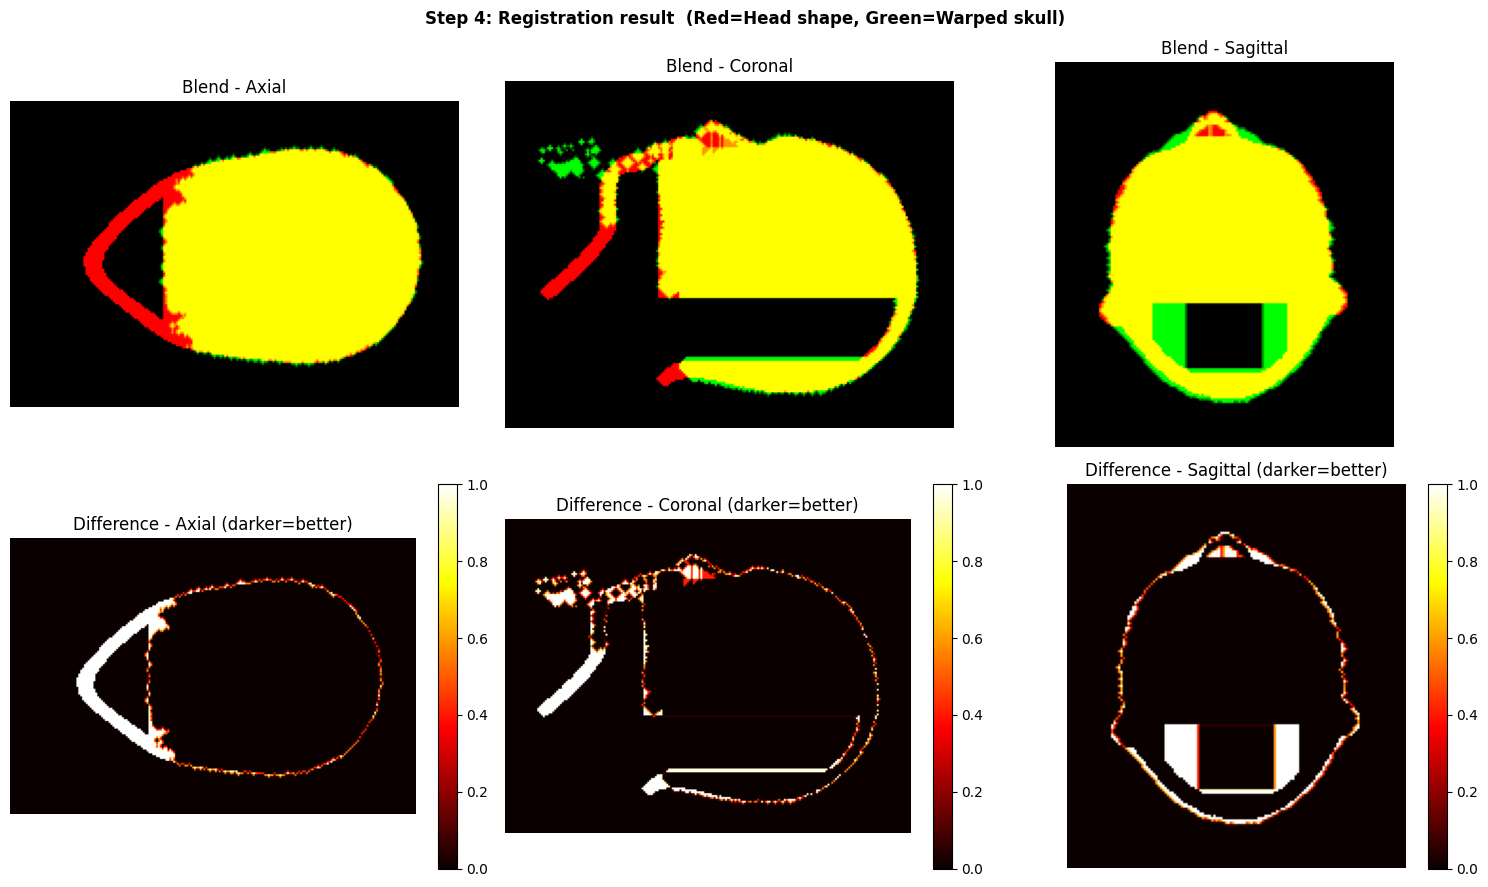

Dice: 0.8795   IoU: 0.7849


In [19]:
def norm(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

# Rebuild warped skull image for blend view (skull-surface-only registration result)
warped_img = nodes_to_ants_volume(nm_skull_warped, pitch=VOXEL_PITCH)
warped_on_fixed = ants.resample_image_to_target(warped_img, fixed_img)

f_arr = norm(fixed_img.numpy())
m_arr = norm(warped_on_fixed.numpy())
z, y, x = [d//2 for d in f_arr.shape]

views = [(f_arr[z], m_arr[z], 'Axial'),
         (f_arr[:,y], m_arr[:,y], 'Coronal'),
         (f_arr[:,:,x], m_arr[:,:,x], 'Sagittal')]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Step 4: Registration result  (Red=Head shape, Green=Warped skull)', fontweight='bold')
for col, (fs, ms, lbl) in enumerate(views):
    rgb = np.zeros((*fs.shape, 3), np.float32)
    rgb[...,0] = fs; rgb[...,1] = ms
    axes[0,col].imshow(rgb, origin='lower'); axes[0,col].axis('off')
    axes[0,col].set_title(f'Blend - {lbl}')
    diff = np.abs(fs - ms)
    im = axes[1,col].imshow(diff, cmap='hot', origin='lower'); axes[1,col].axis('off')
    plt.colorbar(im, ax=axes[1,col], fraction=0.046)
    axes[1,col].set_title(f'Difference - {lbl} (darker=better)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'registration_result.png'), dpi=120)
plt.show()

# Dice + IoU
fb = (f_arr > 0.1).astype(np.float32)
mb = (m_arr > 0.1).astype(np.float32)
inter = (fb * mb).sum()
dice = 2*inter / (fb.sum() + mb.sum() + 1e-8)
iou  = inter / (fb.sum() + mb.sum() - inter + 1e-8)
print(f'Dice: {dice:.4f}   IoU: {iou:.4f}')


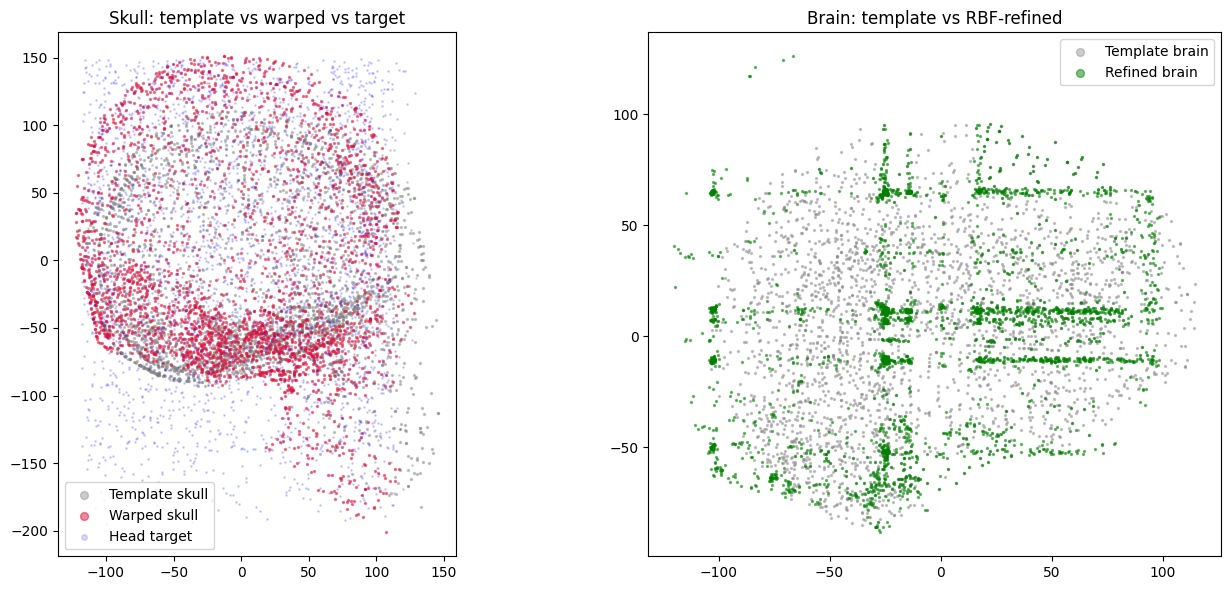

In [21]:
# 3D scatter — original vs warped skull, and brain
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

s = np.random.choice(len(nm_skull_cs), min(3000, len(nm_skull_cs)), replace=False)
axes[0].scatter(nm_skull_cs[s,0],     nm_skull_cs[s,2],     s=2, c='gray',    alpha=0.4, label='Template skull')
axes[0].scatter(nm_skull_warped[s,0], nm_skull_warped[s,2], s=2, c='crimson', alpha=0.5, label='Warped skull')
axes[0].scatter(nf_c[np.random.choice(len(nf_c), 3000), 0],
                 nf_c[np.random.choice(len(nf_c), 3000), 2],
                 s=1, c='blue', alpha=0.15, label='Head target')
axes[0].set_title('Skull: template vs warped vs target')
axes[0].set_aspect('equal'); axes[0].legend(markerscale=4)

b = np.random.choice(len(nm_brain_cs), min(3000, len(nm_brain_cs)), replace=False)
axes[1].scatter(nm_brain_cs[b,0],      nm_brain_cs[b,2],      s=2, c='gray',  alpha=0.4, label='Template brain')
axes[1].scatter(nm_brain_refined[b,0], nm_brain_refined[b,2], s=2, c='green', alpha=0.5, label='Refined brain')
axes[1].set_title('Brain: template vs RBF-refined')
axes[1].set_aspect('equal'); axes[1].legend(markerscale=4)

plt.tight_layout(); plt.show()

## Step 5 — Save & validateUndo the centre+scale normalization to return to original world coordinates,write the warped VTU (preserving all cell/point data), and print validation metrics.

In [22]:
# Reassemble full warped mesh in ORIGINAL world coordinates
def to_world(nodes_cs):
    return (nodes_cs / scale) + c_moving

# Start from original positions, then overwrite skull and brain subsets
# with their respective correctly-fitted results
final_nodes_cs = nm_all_cs.copy()

skull_orig_ids = skull_sub.point_data.get('vtkOriginalPointIds', None)
brain_orig_ids = brain_sub.point_data.get('vtkOriginalPointIds', None)

if skull_orig_ids is not None:
    final_nodes_cs[skull_orig_ids] = nm_skull_warped
else:
    print('WARNING: no vtkOriginalPointIds on skull_sub')

if brain_orig_ids is not None:
    final_nodes_cs[brain_orig_ids] = nm_brain_refined
else:
    print('WARNING: no vtkOriginalPointIds on brain_sub')

final_nodes_world = to_world(final_nodes_cs)

registered = moving_mesh.copy(deep=True)
registered.points = final_nodes_world
disp_world = np.linalg.norm(final_nodes_world - nm_all, axis=1)
registered.point_data['displacement_mm'] = disp_world.astype(np.float32)

out_vtu = os.path.join(OUTPUT_DIR, f'{stem}_registered_final.vtu')
registered.save(out_vtu, binary=True)

print('=' * 55)
print('VALIDATION')
print('=' * 55)
print(f'Output: {out_vtu}  ({os.path.getsize(out_vtu)/1e6:.1f} MB)')
print(f'Points: {registered.n_points:,}   Cells: {registered.n_cells:,}')
print(f'Displacement (world): mean {disp_world.mean():.2f}  max {disp_world.max():.2f} mm')

try:
    jac = ants.create_jacobian_determinant_image(fixed_img, reg['fwdtransforms'][0])
    jarr = jac.numpy()
    neg = int((jarr < 0).sum())
    status = 'OK no folding' if neg == 0 else 'WARNING folding present'
    print(f'Jacobian: min {jarr.min():.3f}  negatives {neg}  ({status})')
except Exception as e:
    print(f'Jacobian check skipped: {e}')


VALIDATION
Output: /Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6_registered_final.vtu  (10.7 MB)
Points: 179,676   Cells: 256,571
Displacement (world): mean 11.31  max 107.66 mm
Jacobian: min 0.000  negatives 0  (OK no folding)


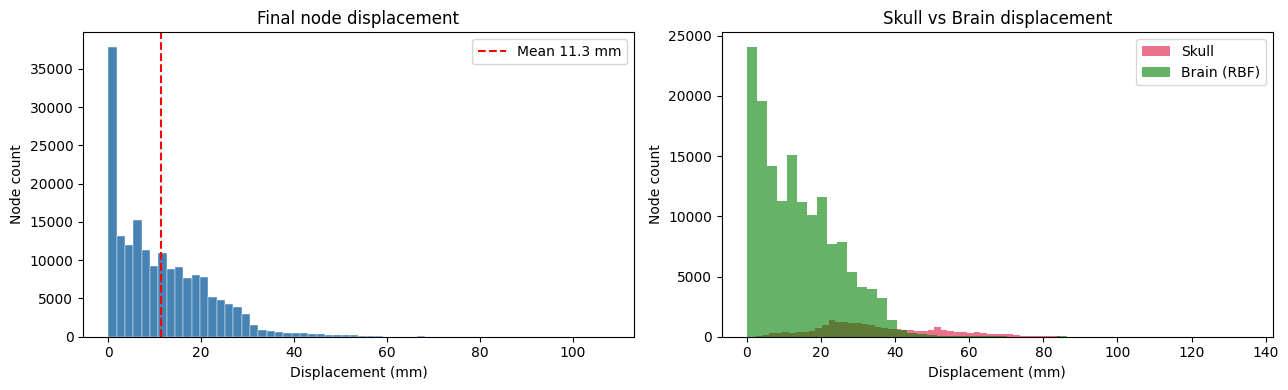

Pipeline complete. Open _registered_final.vtu in ParaView,
colour by displacement_mm to inspect the warp field.


In [23]:
# Final displacement histograms
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(disp_world, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax[0].axvline(disp_world.mean(), color='red', ls='--', label=f'Mean {disp_world.mean():.1f} mm')
ax[0].set_xlabel('Displacement (mm)'); ax[0].set_ylabel('Node count')
ax[0].set_title('Final node displacement'); ax[0].legend()

ax[1].hist(skull_disp, bins=50, alpha=0.6, label='Skull', color='crimson')
ax[1].hist(rb, bins=50, alpha=0.6, label='Brain (RBF)', color='green')
ax[1].set_xlabel('Displacement (mm)'); ax[1].set_ylabel('Node count')
ax[1].set_title('Skull vs Brain displacement'); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_final.png'), dpi=120)
plt.show()

print('Pipeline complete. Open _registered_final.vtu in ParaView,')
print('colour by displacement_mm to inspect the warp field.')
